# Домашнее задание 3 (продвинутая группа)

## Тема: Аналитика вакансий и факторов стоимости аренды в Москве

### Описание работы

В этой работе предстоит:
- Провести базовый EDA и очистку данных по вакансиям
- Построить вспомогательные признаки и простые визуализации
- Исследовать факторы, влияющие на цену аренды

---

## Общий формат выполнения

* Все задания разбиты на пункты с оценкой в баллах
* Под каждым заданием напишите ваш код/ответ в соответствующем блоке
* У всех графиков обязательны **подписи осей**, **заголовки** и **читаемая легенда**

---

## Импорт библиотек и настройка визуализации

**Рекомендуемые библиотеки:**

```python
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
```

---

## 🧩 Задача 1. Аналитика по вакансиям (45 баллов)

Датасет: [скачать](https://disk.yandex.ru/d/QUa3pCKVk48cAQ)
Считайте данные с помощью `pd.read_csv`.

In [1]:
import pandas as pd
import numpy as np
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)

PATH = "vacancies.csv"
df = pd.read_csv(PATH)

#### 1.0. Загрузка и первичный обзор данных (1 балл)

Выведите первые 5 и последние 5 строк.
Примените `info()` и `describe()`.

> Сделайте краткий вывод по результатам анализа.

In [2]:
# ваш код тут

display(df.head(5))
display(df.tail(5))
df.info()
display(df.describe(include=[np.number]))
display(df.describe(include=['object']))

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB


,Unnamed: 0
count,1527.000000
mean,763.000000
std,440.951244
min,0.000000
25%,381.500000
50%,763.000000
75%,1144.500000
max,1526.000000


,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
count,1527,1527,1527,1527,1527,1527,1527,220,1527,1527
unique,793,524,102,4,5,4,36,130,1232,653
top,Data Engineer,СБЕР,Москва,От 3 до 6 лет,Полный день,Полная занятость,Дата-сайентист,"{'from': 100000, 'to': 110000, 'currency': 'RU...",<p>Striving to gain market-oriented knowledge ...,[]
freq,126,146,912,724,1098,1464,464,20,46,607


#### 1.1 Размерность датасета (1 балл)

Сколько в датасете строк и столбцов?

In [3]:
# ваш код тут=
rows, cols = df.shape
print(rows, cols)

1527 11


#### 1.2. Пропуски (1 балл)

Проверьте наличие пропусков и где они встречаются.

> Сделайте краткий вывод по результатам анализа. Насколько данные качественные?

In [4]:
# ваш код тут
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


,missing
salary,1307
position_name,0
Unnamed: 0,0
employer_name,0
area,0
schedule,0
experience,0
employment,0
professional_roles,0
description,0


#### 1.3. Дубликаты (1 балл)

Проверьте, есть ли в датасете полные дубликаты. Если есть, удалите их.

In [9]:
# ваш код тут

df = df.drop_duplicates().reset_index(drop=True)


#### 1.4. Уникальные профессиональные роли (1 балл)

Определите количество уникальных значений `professional_roles`.

In [10]:
# ваш код тут
print(df["professional_roles"].nunique(dropna=True))



36


#### 1.5. Вакансии без требования опыта (2 балла)

Подсчитайте количество вакансий, не требующих опыта работы.

In [11]:
# ваш код тут вуа

def _no_exp(x):
    if pd.isna(x):
        return True
    s = str(x).lower()
    return ("-опыта" in s) or ("no experience" in s)
print(df["experience"].apply(_no_exp).sum())


136



#### 1.6. Среднее количество навыков (2 балла)

Рассчитайте среднее количество навыков в поле `key_skills`.

In [12]:
# ваш код тут

def _parse_skills(s):
    if pd.isna(s):
        return []
    s = str(s).strip()
    if s in ("", "[]"):
        return []
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, list):
            return obj
        return [x.strip() for x in s.split(",") if x.strip()]
    except Exception:
        return [x.strip() for x in s.split(",") if x.strip()]
df["key_skills_list"] = df["key_skills"].apply(_parse_skills)
print(df["key_skills_list"].map(len).mean())

3.8749181401440733


#### 1.7. Валюты заработной платы (2 балла)

Определите, какие валюты используются для заработной платы (ключ currency в поле salary). Создайте столбец currency.

In [13]:
# ваш код тут

def _parse_salary(s):
    if pd.isna(s):
        return None
    try:
        obj = ast.literal_eval(str(s))
        return obj if isinstance(obj, dict) else None
    except Exception:
        return None
df["salary_parsed"] = df["salary"].apply(_parse_salary)
df["currency"] = df["salary_parsed"].apply(lambda d: d.get("currency") if isinstance(d, dict) else None)
print(sorted(df["currency"].dropna().unique()))


['BYR', 'EUR', 'KZT', 'RUR', 'USD', 'UZS']


#### 1.8. Частота профессиональных ролей (3 балла)

Постройте таблицу частот по `professional_roles` и визуализируйте топ-10 ролей (`barplot`).

> Сделайте краткий вывод по результатам анализа.

,count
professional_roles,
Дата-сайентист,464
"BI-аналитик, аналитик данных",283
"Программист, разработчик",260
Аналитик,255
Другое,96
"Менеджер по продажам, менеджер по работе с клиентами",23
Руководитель группы разработки,23
Руководитель проектов,16
Руководитель отдела аналитики,12


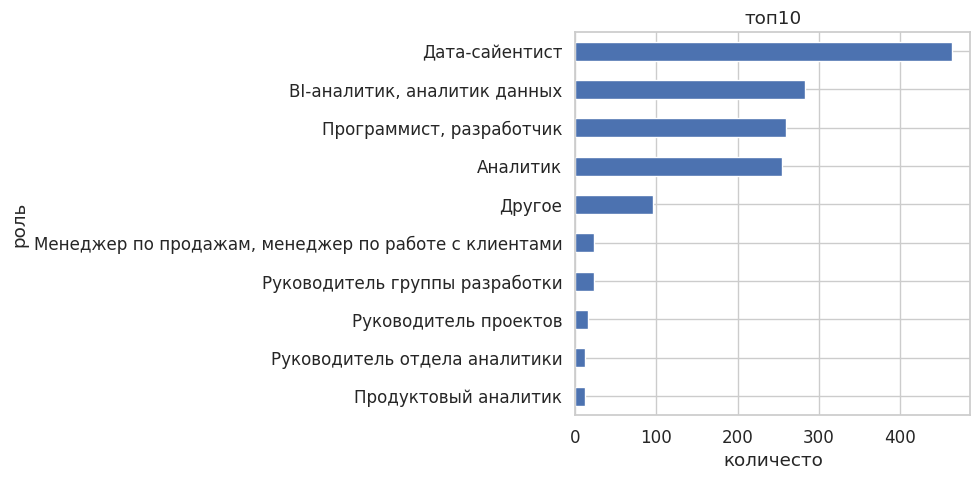

In [16]:
role_counts = df["professional_roles"].value_counts()
display(role_counts.head(10).to_frame("count"))
plt.figure()
role_counts.head(10)[::-1].plot(kind="barh")
plt.title("топ10")
plt.xlabel("количесто")
plt.ylabel("роль")
plt.tight_layout()
plt.show()


#### 1.9. Компания-лидер (1 балл)

Какая компания лидирует по количеству вакансий с указанием заработной платы? А в целом по кол-ву вакансий, без учета наличия заработной платы в вакансии?

In [15]:
has_salary = df["salary_parsed"].notna()
leader_with_salary = df.loc[has_salary, "employer_name"].value_counts().idxmax() if has_salary.any() else None
leader_overall = df["employer_name"].value_counts().idxmax() if df["employer_name"].notna().any() else None
print(leader_with_salary, leader_overall)


Aston СБЕР


#### 1.10. Создание столбца salary_num (2 балла)

Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в этом столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to), используйте его.

In [17]:
def _to_float(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    try:
        s = str(x).strip().lower()
        if s in ("", "none", "null", "nan"):
            return np.nan
        return float(s)
    except Exception:
        try:
            return float(x)
        except Exception:
            return np.nan

def _salary_num(d):
    if not isinstance(d, dict):
        return np.nan
    f = _to_float(d.get("from", np.nan))
    t = _to_float(d.get("to", np.nan))
    if not np.isnan(f) and not np.isnan(t):
        return (f + t) / 2
    if not np.isnan(f):
        return f
    if not np.isnan(t):
        return t
    return np.nan
df["salary_num"] = df["salary_parsed"].apply(_salary_num)


#### 1.11. Средняя и медианная зарплата (2 балла)

Какая средняя заработная плата среди вакансий в рублях? А средняя и медианная заработная плата по 10 наиболее частым позициям в датасете в рублях?

In [18]:
rub = df["currency"].isin(["RUR", "RUB"])
print(df.loc[rub, "salary_num"].mean())
top10_roles = df["professional_roles"].value_counts().head(10).index
stats_top10 = (
    df.loc[rub & df["professional_roles"].isin(top10_roles), ["professional_roles", "salary_num"]]
      .groupby("professional_roles")
      .agg(mean_salary=("salary_num", "mean"), median_salary=("salary_num", "median"))
      .sort_values("mean_salary", ascending=False)
)
display(stats_top10)

212395.02762430938


,mean_salary,median_salary
professional_roles,,
Другое,301923.076923,372500.0
"Программист, разработчик",277259.259259,300000.0
Дата-сайентист,210203.125000,200000.0
"Менеджер по продажам, менеджер по работе с клиентами",207500.000000,207500.0
Аналитик,180396.000000,150000.0
"BI-аналитик, аналитик данных",164552.500000,120000.0
Продуктовый аналитик,152500.000000,152500.0
Руководитель группы разработки,150000.000000,150000.0


#### 1.12. Требование знания Python (3 балла)

Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python). Какой процент вакансий требует знания python?

In [ ]:
def _has_python(sk):
    if isinstance(sk, list):
        text = " ".join(map(str, sk)).lower()
    else:
        text = str(sk).lower()
    return 1 if "python" in text else 0
df["is_python_requirement"] = df["key_skills_list"].apply(_has_python)
print(100 * df["is_python_requirement"].mean())


#### 1.13. Группировка по нескольким признакам (3 балла)

Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях

In [ ]:
grp = (
    df.groupby(["experience", "schedule", "employment", "is_python_requirement"])
      .agg(
          vacancies=("position_name", "count"),
          companies=("employer_name", "nunique"),
          mean_salary_rub=("salary_num", lambda s: s[df.loc[s.index, "currency"].isin(["RUR","RUB"])].mean())
      )
      .reset_index()
      .sort_values("vacancies", ascending=False)
)
display(grp)




#### 1.14. Подсчет количества навыков (3 балла)

Создайте столбец count_skills. В нём должна быть длина списка, который находится в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]'. Подумайте, как превратить её в список и посчитать его длину.

In [19]:
df["count_skills"] = df["key_skills_list"].map(len)
display(df[["key_skills", "count_skills"]].head())


,key_skills,count_skills
0,[],0
1,[],0
2,"['SQL', 'Визуализация данных', 'Python', 'Powe...",11
3,[],0
4,"['Английский язык', 'Аналитический склад ума']",2




#### 1.15. Описание без HTML-тегов (3 балла)

Создайте столбец filtered_descr, в котором должны быть описания (description) в символах без учета HTML-тегов ("<...>"). Напишите для этого функцию get_descr. Можете использовать регулярные выражения или самостоятеьно написанный код.


In [20]:
import re
def get_descr(descr):
    if pd.isna(descr):
        return ""
    s = re.sub(r"<[^>]*>", "", str(descr))
    return re.sub(r"\s+", " ", s).strip()
df["filtered_descr"] = df["description"].apply(get_descr)


#### 1.16. Таблица корреляций (1 балл)

Постройте таблицу корреляций с тремя переменными: `salary_num`, `len_descr`, `count_skills`, где `len_descr` - новый столбец, равный длине строки в столбце `filtered_descr`.

In [21]:
df["len_descr"] = df["filtered_descr"].map(len)
corr = df[["salary_num", "len_descr", "count_skills"]].corr()
display(corr)

,salary_num,len_descr,count_skills
salary_num,1.000000,0.001153,-0.011834
len_descr,0.001153,1.000000,0.125369
count_skills,-0.011834,0.125369,1.000000


#### 1.17. Тепловая карта корреляций (1 балл)

Постройте тепловую карту из таблицы из предыдущего пункта.

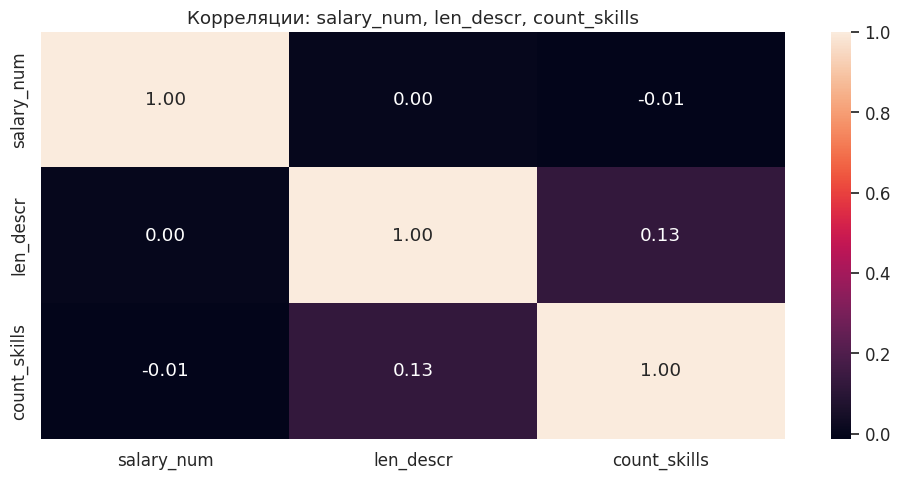

In [22]:
plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f", cbar=True)
plt.title("Корреляции: salary_num, len_descr, count_skills")
plt.tight_layout()
plt.show()

#### 1.18. Топ-10 требуемых навыков (3 балла)

Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

,skill,count
0,Python,633
1,SQL,574
2,ETL,154
3,Big Data,146
4,Hadoop,118
5,PostgreSQL,113
6,DWH,111
7,Clickhouse,102
8,Английский язык,93
9,Математический анализ,90


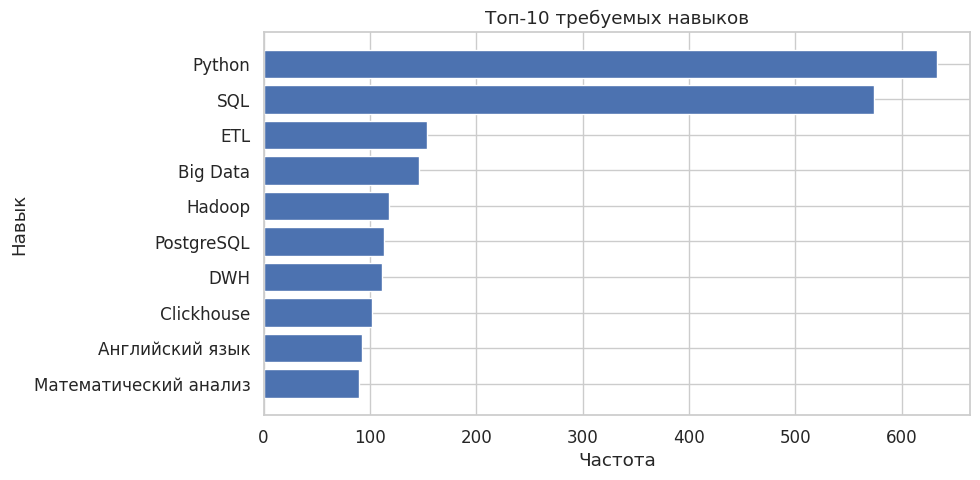

In [23]:
all_skills = Counter()
for lst in df["key_skills_list"]:
    all_skills.update([str(x).strip() for x in lst if str(x).strip()])
top10_sk = pd.DataFrame(all_skills.most_common(10), columns=["skill", "count"])
display(top10_sk)
plt.figure()
plt.barh(top10_sk["skill"][::-1], top10_sk["count"][::-1])
plt.title("Топ-10 требуемых навыков")
plt.xlabel("Частота")
plt.ylabel("Навык")
plt.tight_layout()
plt.show()

#### 1.19. Распределение зарплаты (3 балла)

Постройте гистограмму распределения зарплаты среди вакансий в рублях.

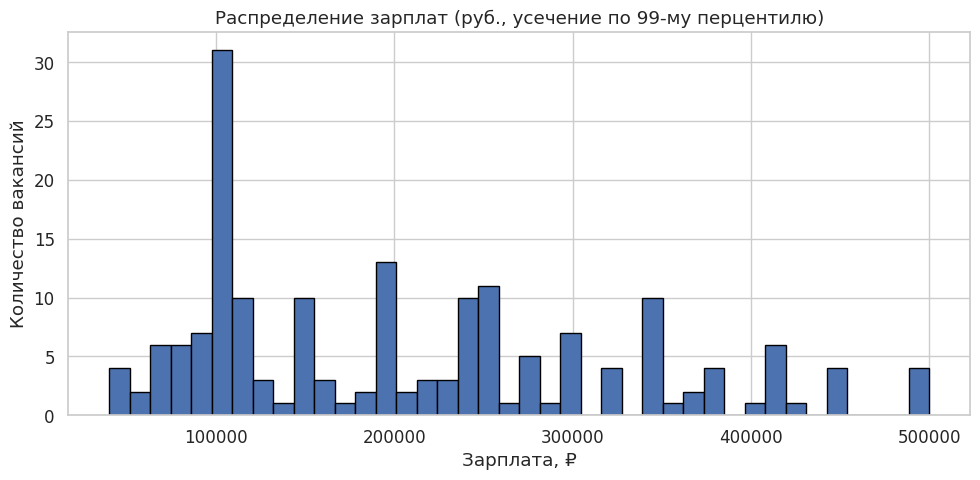

In [24]:
rub_salaries = df.loc[rub, "salary_num"].dropna()
if len(rub_salaries) > 0:
    ub = np.percentile(rub_salaries, 99)
    plt.figure()
    plt.hist(rub_salaries[rub_salaries <= ub], bins=40, edgecolor="black")
    plt.title("Распределение зарплат (руб., усечение по 99-му перцентилю)")
    plt.xlabel("Зарплата, ₽")
    plt.ylabel("Количество вакансий")
    plt.tight_layout()
    plt.show()


#### 1.20. Boxplot зарплаты по опыту работы (3 балла)

Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience.

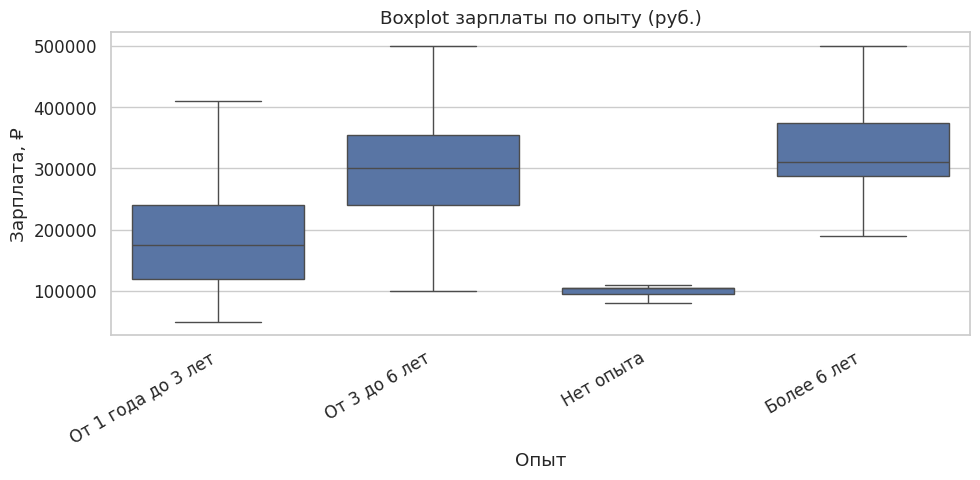

In [25]:
if len(rub_salaries) > 0:
    subset = df.loc[rub & df["salary_num"].notna(), ["experience", "salary_num"]].copy()
    order = subset["experience"].value_counts().index.tolist()
    plt.figure()
    sns.boxplot(data=subset, x="experience", y="salary_num", order=order, showfliers=False)
    plt.title("Boxplot зарплаты по опыту (руб.)")
    plt.xlabel("Опыт")
    plt.ylabel("Зарплата, ₽")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

#### 1.21. Собственный исследовательский вопрос (до 3 баллов)

Попробуйте ответить на какой-нибудь вопрос по данным, не заданный ранее. Никак не ограничиваем вашу фантазию и покажите весь уровень вашего владения `pandas`.


In [ ]:
# ваш код тут

---

## Задача 2. 25 баллов

Работаем с датасетом https://disk.yandex.ru/d/P6u1Za-nnmtwPA
Скачайте его.

Оцениваем факторы, которые влияют на цену на аренду в Москве.

Описание столбцов:

| Переменная     | Описание                                     |
|----------------|----------------------------------------------|
| metro          | ближайшая станция метро                      |
| price          | цена за аренду                               |
| minutes        | расстояние до метро в минутах                |
| way            | путь до метро (пешком или на транспорте)     |
| views          | просмотры квартиры                           |
| provider       | кто сдает квартиру (собственник и др.)       |
| fee_percent    | процент, который получает риелтор            |
| storey         | этаж                                         |
| storeys        | число этажей в здании                        |
| living_area    | жилая площадь                                |
| kitchen_area   | площадь кухни                                |
| total_area     | общая площадь                                |



In [ ]:
import pandas as pd
df = pd.read_csv('rent.csv', index_col=0)

#### 2.1. Первичный обзор данных (1 балл)

Отобразите первые 5 и последние 5 строк датасета.

#### 2.2. Описательные статистики (1 балл)

Посчитайте описательные статистики числовых переменных с помощью describe(). Есть ли какие-то инсайты?

> Ответ текстом

#### 2.3. Статистики категориальных переменных (1 балл)

Посчитайте статистики по категориальным переменным. Сколько уникальных значений у переменной metro?

#### 2.4. Пропуски (1 балл)

Проверьте, есть ли в датасете пропуски. Если есть, укажите в каких столбцах они встречаются и сколько их.

#### 2.5. Дубликаты (2 балла)

Проверьте, есть ли в датасете полные дубликаты. Если есть, удалите их.

#### 2.6. Анализ переменной provider (3 балла)

Определите количество уникальных значений у переменной provider. Есть ли со значениями этой переменной какие-нибудь проблемы? Если да, то как их исправить?

> Ответ текстом

#### 2.7. Гистограммы распределения (2 балла)

Постройте гистограммы распределения всех числовых переменных. Обязательно подпишите график и оси.

#### 2.8. Функция для scatter plot (4 балла)

Напишите функцию, которая принимает на вход датасет, названия столбцов, название графика и осей и рисует scatter plot. Нарисуйте с её помощью не менее трёх scatterplot.

#### 2.9. Pairplot (1 балл)

Постройте scatterplot всех пар переменных с помощью sns.pairplot.

#### 2.10. Boxplot цены аренды (2 балла)

Нарисуйте boxplot переменной price.

#### 2.11. Дополнительная визуализация (2 балла)

Нарисуйте любой график, который считаете красивым и нужным (а вы слышлаи про lmplot?).

#### 2.12. Анализ визуализаций (2 балла)

Какие выводы можно сделать из визуализаций 7-11?

> Ответ текстом

#### 2.13. Корреляционный анализ (3 балла)

Постройте таблицу корреляций и тепловую карту числовых переменных. Между какими переменными наблюдается линейная связь?

> Ответ текстом